In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("../retailiq.db")

query = """
SELECT
    o.order_id,
    JULIANDAY(o.order_delivered_customer_date) - JULIANDAY(o.order_purchase_timestamp) AS delivery_days,
    JULIANDAY(o.order_delivered_customer_date) - JULIANDAY(o.order_estimated_delivery_date) AS delay_days,
    p.payment_value,
    p.payment_installments,
    r.review_score,
    oi.price,
    oi.freight_value
FROM orders_clean o
JOIN payments_clean p ON o.order_id = p.order_id
JOIN reviews_clean r ON o.order_id = r.order_id
JOIN order_items_clean oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL
"""
merged = pd.read_sql(query, conn)
print(merged.shape)
merged.head()

(114847, 8)


,order_id,delivery_days,delay_days,payment_value,payment_installments,review_score,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,-7.107488,2.00,1,4,29.99,8.72
1,e481f51cbdc54678b7cc49136f2d6af7,8.436574,-7.107488,18.12,1,4,29.99,8.72
2,e481f51cbdc54678b7cc49136f2d6af7,8.436574,-7.107488,18.59,1,4,29.99,8.72
3,53cdb2fc8bc7dce0b6741e2150273451,13.782037,-5.355729,141.46,1,4,118.70,22.76
4,47770eb9100c2d0c44946d9cf07ec65d,9.394213,-17.245498,179.12,3,5,159.90,19.22


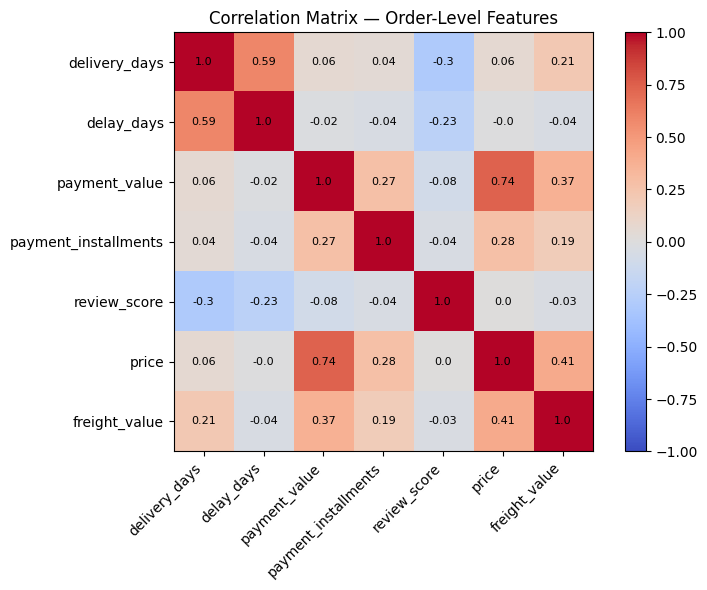

In [2]:
import numpy as np

corr_cols = ["delivery_days", "delay_days", "payment_value", "payment_installments", "review_score", "price", "freight_value"]
corr_matrix = merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, round(corr_matrix.iloc[i,j], 2), ha="center", va="center", fontsize=8)
plt.colorbar(im)
plt.title("Correlation Matrix — Order-Level Features")
plt.tight_layout()
plt.show()

   customer_state  order_count  avg_order_value
0              SP        40500           136.39
1              RJ        12350           158.11
2              MG        11354           154.12
3              RS         5345           155.45
4              PR         4923           152.45
5              SC         3546           162.58
6              BA         3256           169.76
7              DF         2080           161.60
8              ES         1995           153.69
9              GO         1957           163.39
10             PE         1593           185.41
11             CE         1279           198.71
12             PA          946           216.13
13             MT          886           199.61
14             MA          717           201.10
15             MS          701           186.18
16             PB          517           250.15
17             PI          476           208.87
18             RN          474           197.12
19             AL          397          

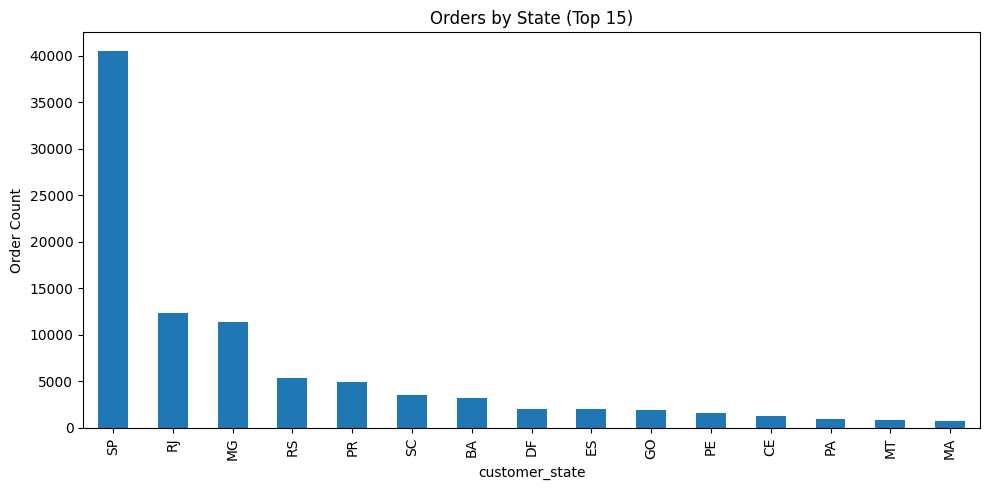

In [3]:
geo_query = """
SELECT
    c.customer_state,
    COUNT(DISTINCT o.order_id) AS order_count,
    ROUND(AVG(p.payment_value), 2) AS avg_order_value
FROM orders_clean o
JOIN customers_clean c ON o.customer_id = c.customer_id
JOIN payments_clean p ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state
ORDER BY order_count DESC
"""
geo_df = pd.read_sql(geo_query, conn)
print(geo_df)

fig, ax = plt.subplots(figsize=(10, 5))
geo_df.head(15).plot(kind="bar", x="customer_state", y="order_count", ax=ax, legend=False)
ax.set_title("Orders by State (Top 15)")
ax.set_ylabel("Order Count")
plt.tight_layout()
plt.show()

conn.close()